# Tutorial 2: DP-Accounting

The main aim of today's lab is to familiarize you with Google's `dp-accounting` library which will be used for the remainder of this course to implement, test and account for various differentially private algorithms and mechanisms.

The lab consists of the following tasks:

1. Exploring Gaussian DP Mechanism:
    1. Analyse the effect of the noise multiplier on the value of $\epsilon$ obtained for multiple values of $\delta$ as shown in the code cell below. Plot the results with a log-scale for both axes
    2. Calculate the average slopes of the lines traced by The plot of the $\epsilon$ vs Noise Multiplier in the log-log scale for various values of $\delta$.

2. For 1 to 100 composed DP mechanisms each of which guarantee (0.1, 0)-DP, plot and compare the obtained values of epsilon for each composition method (basic, advanced and PLD) for a value of $\delta=10^{-6}$

3. For given noise parameter and delta, plot the privacy guarantees obtained for subsampled gaussian DP events, along with the calculated values using the equation $\epsilon_p = \log(1 + p(e^\epsilon-1))$

4. Privacy accounting for DP SGD:
    1. For given range of training steps, sampling rates and delta, plot the value of $\epsilon$ obtained for DP SGD for various values of the noise multiplier
    2. For given range of training steps, noise multiplier and delta, plot the value of $\epsilon$ obtained for various values of the subsampling rates
  
5. Plot the optimal required noise parameters to ensure various privacy guarantees for DP SGD for the given set of sampling ratios and epsilons

## Preliminaries

### 1. Neighbouring Datasets

Two datasets $D$ and $D'$ are said to be neighbouring if they differ in exactly one element.  
Formally, there exists an element $x$ such that either

$$
D = D' \cup \{x\}
\quad \text{or} \quad
D' = D \cup \{x\},
$$

and therefore

$$
\lvert |D| - |D'| \rvert = 1.
$$

Question: Can this statement can be extended to datasets that differ in multiple datapoints instead of a singular datapoint?

### 2. Randomised Algorithm

Let $\mathcal{X}^*$ denote the space of all possible datasets, and let $\mathcal{Y}$ denote the output space.

A deterministic algorithm is a mapping

$$
A : \mathcal{X}^* \to \mathcal{Y}.
$$

A randomised algorithm (or mechanism) $\mathcal{A}$ is a mapping

$$
\mathcal{A} : \mathcal{X}^* \to \mathcal{P}(\mathcal{Y}),
$$

where $\mathcal{P}(\mathcal{Y})$ denotes the set of all probability distributions over $\mathcal{Y}$.

Equivalently, for each dataset $D \in \mathcal{X}^*$, the output $\mathcal{A}(D)$ is a random variable taking values in $\mathcal{Y}$.

In differential privacy, a randomised algorithm is typically obtained by adding carefully calibrated noise to the output of a deterministic function $A$.  
The magnitude of this noise is chosen to balance privacy (protection of individual data) and utility (accuracy of the output).

### 3. $\varepsilon$-Differential Privacy

A randomised algorithm 
$\mathcal{A} : \mathcal{X}^* \to \mathcal{P}(\mathcal{Y})$ 
is said to satisfy $\varepsilon$-differential privacy if for all neighbouring datasets 
$D \sim D'$ and for all measurable output subsets $\mathcal{S} \subseteq \mathcal{Y}$,

$$
e^{-\varepsilon}
\mathbb{P}\big(\mathcal{A}(D') \in \mathcal{S}\big)
\;\le\; 
\mathbb{P}\big(\mathcal{A}(D) \in \mathcal{S}\big)
\;\le\;
e^{\varepsilon}
\mathbb{P}\big(\mathcal{A}(D') \in \mathcal{S}\big).
$$

$\varepsilon$ is a measure of how far the distributions are for $D$ and $D'$.

## Imports

We first install `dp-accounting` and then make all the necessary imports to be used in the remainder of the lab.

In [2]:
### DO NOT EDIT ###

! pip install dp-accounting

import numpy as np
import dp_accounting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import optimize as opt

sns.set_style('darkgrid')

from dp_accounting import dp_event as event
from dp_accounting.pld import pld_privacy_accountant as pld
from dp_accounting.rdp import rdp_privacy_accountant as rdp

### DO NOT EDIT ###

Defaulting to user installation because normal site-packages is not writeable


## $(\varepsilon,\delta)$ - Differential Privacy


$\varepsilon$-DP provides a worst-case guarantee on the output distributions.
It requires that the privacy bound hold for all possible outputs, including extremely rare ones.
In this sense, it provides zero tolerance for any violation of the bound.

However, this does not mean that 
$\varepsilon$ must be extremely small. Rather, for many useful mechanisms (such as those based on Gaussian noise), satisfying pure 
$\varepsilon$-DP would require adding significantly more noise than in the approximate 
($\varepsilon$,$\delta$)-DP setting. In practical applications like private SGD, enforcing pure $\varepsilon$-DP can lead to much larger noise levels, which may significantly degrade model utility.

In order to provide some tolerance to these rare outcomes, we define ($\varepsilon,\delta$)-DP as follows:
A randomised algorithm $\mathcal{A}: \chi^* \rightarrow \mathcal{P}(\mathcal{Y})$ is said to satisfy ($\varepsilon$,$\delta$)-differential privacy if for all neighbouring datasets $D \sim D'$ and for all measurable output subsets $\mathcal{S} \subseteq \mathcal{Y}$, we have,

$$
\mathbb{P}\big(\mathcal{A}(D) \in \mathcal{S}\big)
\;\le\;
e^{\varepsilon}
\mathbb{P}\big(\mathcal{A}(D') \in \mathcal{S}\big) + \delta.
$$

Here, $\delta$ represents the maximum probability that the mechanism’s privacy guarantee may exceed the $\varepsilon$ bound. $\delta$ is typically of the order of $O(\frac{1}{n})$ or $O(\frac{1}{n^2})$, where $n$ is the size of the dataset.

Question: How can you express the above statement in terms of the Privacy Loss Random Variable? Why can't $\delta$ be a constant?

## Understanding the Gaussian Mechanism

To represent and track the privacy guarantees of differentially private mechanisms, we use the `dp-event` subpackage.  
This package allows us to construct *DP events* corresponding to applications of specific privacy mechanisms and to compose them formally.

For example, `dp_event.GaussianDpEvent` represents an application of the Gaussian mechanism.


### The Gaussian Mechanism

Given a function $f$ with sensitivity $\Delta$, the Gaussian mechanism is defined as

$$
\mathcal{A}(f, x, \varepsilon, \delta)
=
f(x)
+
\mathcal{N}\!\left(
0,\;
\sigma^2
\right),
$$

where the noise variance is chosen as

$$
\sigma^2
=
\frac{2 \log(1.25/\delta)\, \Delta^2}{\varepsilon^2}.
$$

Here:

- $\Delta$ is the sensitivity of $f$, $\Delta = \max_{D \sim D'}|f(D) - f(D')|$,
- $\varepsilon$ controls the privacy level,
- $\delta$ bounds the probability of exceeding the $\varepsilon$ privacy loss.

This mechanism satisfies $(\varepsilon,\delta)$-differential privacy.


### Noise Multiplier

In practice, instead of directly specifying $\sigma$, we use a noise multiplier, defined as

$$
\text{Noise Multiplier}
=
\frac{\sigma}{\Delta}.
$$

This normalizes the noise level by the sensitivity.

Equivalently, we can interpret this as assuming **unit sensitivity** ($\Delta = 1$), in which case

$$
\sigma = \text{Noise Multiplier}.
$$

This formulation makes the noise parameter independent of the particular function’s sensitivity and simplifies privacy accounting, especially when composing multiple mechanisms.


**[Task 1.1] Analyse the effect of the noise multiplier on the value of $\epsilon$ obtained for multiple values of $\delta$ as shown in the code cell below. Plot the results with a log-scale for both axes.**

In [3]:
### DO NOT EDIT ###
noises = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
deltas = [0.1, 0.01, 0.001, 0.0001, 0.00001]
epsilons = {
    0.1: [],
    0.01: [],
    0.001: [],
    0.0001: [],
    0.00001: [],
}
### DO NOT EDIT ###

In [4]:
### DO NOT EDIT ###

for delta in deltas:
    epss = []
    for noise in noises:
        gauss1 = event.GaussianDpEvent(noise)
        accountant = pld.PLDAccountant()
        accountant.compose(gauss1)
        eps = accountant.get_epsilon(target_delta = delta)
        epss.append(eps)
    epsilons[delta] = epss

### DO NOT EDIT ###

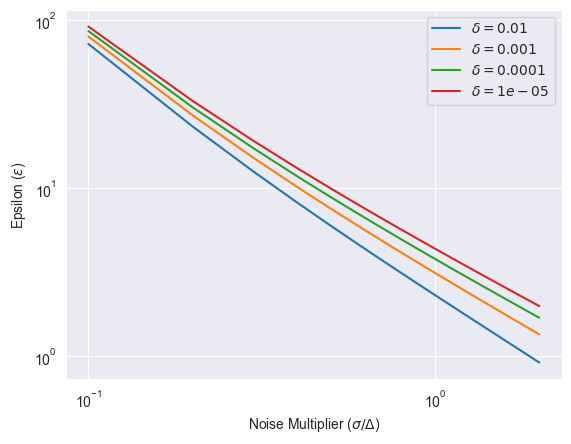

In [5]:
### DO NOT EDIT ###

logscale = 'log'
plt.yscale(logscale)
plt.xscale(logscale)
for delta in deltas[1:]:
    plt.plot(noises[:], epsilons[delta][:], label=r'$\delta={}$'.format(delta))
plt.legend()
plt.xlabel(r'Noise Multiplier ($\sigma/\Delta$)')
plt.ylabel(r'Epsilon ($\epsilon$)')
plt.show()

### DO NOT EDIT ###

### Calculating the Slope of the Line

The plot of the $\epsilon$ vs Noise Multiplier in the log-log scale corresponds to approximately a straight line. This is equivalent to a power law relationship of the form $y=cx^a$ where $a$ is the slope of the line.

**[Task 1.2] Calculate the average slopes of the lines traced by the plot of the $\epsilon$ vs Noise Multiplier in the log-log scale for various values of $\delta$.**

In [ ]:
slopes = []

# Calculate the average slopes of lines in the log-log plot
### WRITE CODE HERE ###
for delta in deltas:
    lognoise = 
    logeps = 
    slopes = 
### WRITE CODE HERE ###

avgslope = sum(slopes)/len(slopes)
print('Average Slope:', avgslope)

Average Slope: -1.4407470825417814


## Exploring Composition

When multiple differentially private mechanisms are applied to the same dataset,
we use the **composition properties of differential privacy** to determine the
overall privacy guarantee.

 **Note**: In this tutorial, we focus on compositions of pure
$(\varepsilon, 0)$-DP mechanisms.


### 1. Basic Composition

If we apply $n$ mechanisms with privacy guarantees
$(\varepsilon_i, 0)_{i=1}^n$, then their composition satisfies

$$
\left(\sum_{i=1}^{n} \varepsilon_i,\; 0\right)\text{-DP}.
$$

In other words, privacy losses add linearly.

This bound is simple and always valid, but can be loose when $n$ is large.


### 2. Advanced Composition

Advanced composition provides a tighter bound by allowing a small failure
probability $\delta > 0$.

If we compose $n$ mechanisms, each satisfying $(\varepsilon_i, 0)$-DP,
then for any $\delta > 0$, the composition satisfies
$(\varepsilon, \delta)$-DP, where

$$
\varepsilon
=
\frac{1}{2}\sum_{i=1}^{n} \varepsilon_i^2
+
\sqrt{
2 \log\!\left(\frac{1}{\delta}\right)
\sum_{i=1}^{n} \varepsilon_i^2
}.
$$

In the common case where all $\varepsilon_i = \varepsilon$ and
$\varepsilon$ is small, this simplifies approximately to

$$
\varepsilon_{\text{total}}
\approx
\frac{1}{2} n \varepsilon^2
+
\sqrt{
2 n \varepsilon^2 \log\!\left(\frac{1}{\delta}\right)
}.
$$

This bound grows roughly like $\sqrt{n}$ rather than $n$,
which is significantly tighter for large compositions.

For further details, see Theorem 18 of the referenced note.

### 3. PLD Accountant

The PLD accountant, available in the
`dp-accounting` library, provides significantly tighter privacy bounds
than the classical basic and advanced composition theorems.

Rather than relying on worst-case inequalities, the PLD accountant:

- Tracks the full distribution of privacy loss,
- Enables tighter bounds under composition,
- Is especially useful in iterative settings such as DP-SGD.

In practice, modern DP libraries rely on PLD (or related techniques such as
Rényi Differential Privacy) for accurate privacy accounting.


**[Task 2] For 1 to 100 composed DP mechanisms each of which guarantee (0.1, 0)-DP, plot and compare the obtained values of epsilon for each composition method for a value of $\delta=10^{-6}$.**


Refer to Theorem 18 of [this note](https://arxiv.org/pdf/2210.00597) for further details regarding composition and advanced composition.

In [7]:
### DO NOT EDIT ###

nums = range(1,100)
delta = 1e-6
noise = 10.0

# creating a single DP event with (0.1, 0) DP guarantee
dpevent = event.LaplaceDpEvent(noise)
accountant = pld.PLDAccountant()
accountant.compose(dpevent)
epsilon = accountant.get_epsilon(target_delta = 1e-9)
print('Event Epsilon: {:.2f}'.format(epsilon))

composedepsilons = {
    'pld': [],
    'adv': [],
    'basic': [],
}

### DO NOT EDIT ###

Event Epsilon: 0.10


In [ ]:
for num in nums:
    compevent = event.SelfComposedDpEvent(dpevent, num)
    accountant = pld.PLDAccountant()
    accountant.compose(compevent)

    # Calculate epsilon obtained by basic, advanced composition and the PLD accountant
    ### WRITE CODE HERE ###
    eps1 = 
    eps2 = 
    eps3 = 
    ### WRITE CODE HERE ###

    composedepsilons['pld'].append(eps1)
    composedepsilons['basic'].append(eps2)
    composedepsilons['adv'].append(eps3)

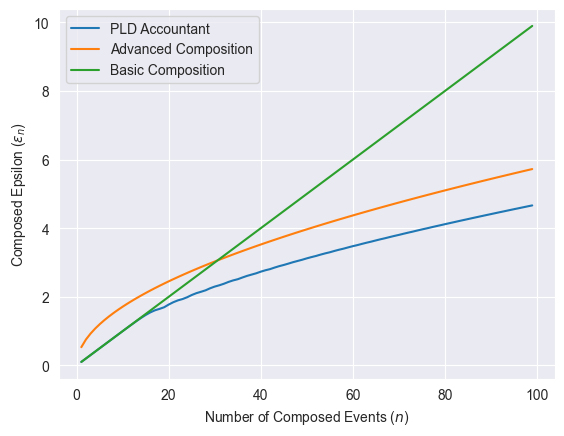

In [9]:
### DO NOT EDIT ###

plt.plot(nums, composedepsilons['pld'], label='PLD Accountant')
plt.plot(nums, composedepsilons['adv'], label='Advanced Composition')
plt.plot(nums, composedepsilons['basic'], label='Basic Composition')

plt.xlabel('Number of Composed Events ($n$)')
plt.ylabel('Composed Epsilon ($\epsilon_n$)')
plt.legend()
plt.show()

### DO NOT EDIT ###

## Exploring Subsampling

Subsampling a dataset before applying a differentially private mechanism
can *amplify* the resulting privacy guarantee.  
This phenomenon is known as privacy amplification by subsampling.

Intuitively, if each individual is included in the computation only with
some probability $p$, then any single individual has a reduced influence
on the output. The additional randomness introduced by subsampling
strengthens privacy protection.


### Poisson Subsampling

We focus on Poisson subsampling, where each element of the dataset
is independently included in the random subset with probability $p$.

For a dataset of size $N$:

- Each element is sampled independently with probability $p$,
- The expected subset size is $pN$,
- The actual subset size is random.


### Privacy Amplification Result

Suppose a mechanism $\mathcal{A}$ satisfies $(\varepsilon, \delta)$-DP
when applied to the full dataset.

If we instead apply $\mathcal{A}$ to a Poisson subsample with inclusion
probability $p$, then the overall mechanism satisfies
$(\varepsilon_p, \delta_p)$-DP, where

$$
\varepsilon_p
=
\log\big(1 + p(e^{\varepsilon} - 1)\big),
\qquad
\delta_p
=
p\,\delta.
$$


### Interpretation

- For small $\varepsilon$, we have
  $e^{\varepsilon} - 1 \approx \varepsilon$,
  so
  $$
  \varepsilon_p \approx p \varepsilon.
  $$

- Thus, subsampling approximately scales the privacy parameter
  linearly by the sampling rate $p$.

- When $p \ll 1$, this can significantly improve privacy guarantees.


**[Task 3] For given noise parameter and delta, plot the privacy guarantees obtained for subsampled gaussian DP events, along with the calculated values using the equation $\epsilon_p = \log(1 + p(e^\epsilon-1))$.**

Question: What if $\varepsilon$ is large? How would the privacy parameter after subsampling look like?

Refer to Theorem 29 of [this note](https://arxiv.org/pdf/2210.00597). Further details may be found in Section 6.1 of the same text.


In [10]:
### DO NOT EDIT ###

rates = np.arange(0.05, 1, 0.05)
delta = 1e-6
noise = 1.5

# Creating a single Gaussian DP event
dpevent = event.GaussianDpEvent(noise)
accountant = pld.PLDAccountant()
accountant.compose(dpevent)
epsilon = accountant.get_epsilon(target_delta = delta)
print(epsilon)

epsilons = []
calcepsilons = []

### DO NOT EDIT ###

3.0976402679539237


In [ ]:
for sampling in rates:
    sampledevent = event.PoissonSampledDpEvent(sampling, dpevent)
    accountant = pld.PLDAccountant()
    accountant.compose(sampledevent)

    # Calculate epsilons obtained by subsampling
    ### WRITE CODE HERE ###
    eps1 =
    eps2 =
    ### WRITE CODE HERE ###

    epsilons.append(eps1)
    calcepsilons.append(eps2)

[np.float64(0.7213854952900188), np.float64(1.136088911866218), np.float64(1.4283583295436375), np.float64(1.6542442208608261), np.float64(1.8383898351988872), np.float64(1.9938413792225713), np.float64(2.128347310659382), np.float64(2.2468876648915277), np.float64(2.3528536227381793), np.float64(2.4486588918302274), np.float64(2.5360826560692495), np.float64(2.6164741740186415), np.float64(2.6908810296010817), np.float64(2.7601328611534943), np.float64(2.8248979173509845), np.float64(2.8857223804355785), np.float64(2.943058397437572), np.float64(2.9972845000674377), np.float64(3.048720766098809)]
[0.7213855008724739, 1.1360889116871142, 1.4283583347945559, 1.6542442248110316, 1.8383898314938159, 1.9938413816292597, 2.1283473128941286, 2.24688766095107, 2.352853624395241, 2.448658892971729, 2.5360826531036746, 2.616474172831566, 2.690881026812269, 2.7601328609205096, 2.8248979091586173, 2.8857223782190613, 2.9430583978301623, 2.997284496050662, 3.0487207633529554]


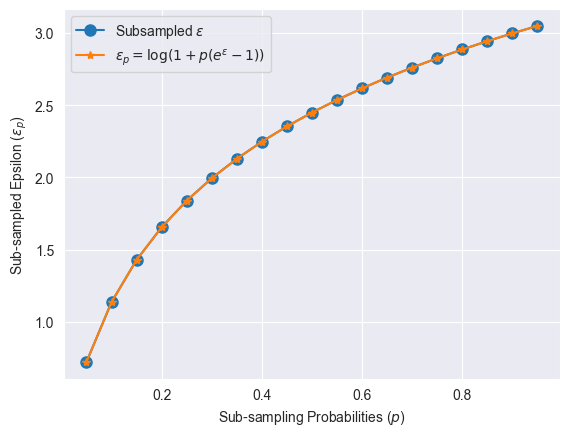

In [12]:
### DO NOT EDIT ###

print(calcepsilons)
print(epsilons)

plt.plot(rates, epsilons, '-o', label=r'Subsampled $\epsilon$', markersize=8)
plt.plot(rates, calcepsilons, '-*', label=r'$\epsilon_p = \log(1 + p(e^\epsilon-1))$')
plt.xlabel('Sub-sampling Probabilities ($p$)')
plt.ylabel('Sub-sampled Epsilon ($\epsilon_p$)')
plt.legend()
plt.show()

### DO NOT EDIT ###

## Privacy Accounting for DP-SGD

DP-SGD, first proposed by Abadi et al.
([Deep Learning with Differential Privacy](https://arxiv.org/pdf/1607.00133)),
provides a method for training machine learning models under
differential privacy by:

1. Clipping per-example gradients to bound sensitivity, and  
2. Adding Gaussian noise to the aggregated gradients.


### Gaussian View of DP-SGD

Each gradient update step can be viewed as a Gaussian DP event:

- Gradients are clipped to a fixed norm $C$ (which bounds sensitivity),
- Gaussian noise is added with variance proportional to $C^2$.

Thus, each update step satisfies $(\varepsilon, \delta)$-DP
(for some step-level parameters),
and the overall privacy guarantee is obtained by composing
these guarantees over all training steps.


### Number of Training Steps

Let:

- $N$ = dataset size,
- $E$ = number of epochs,
- $m$ = batch size.

Then the total number of gradient update steps is

$$
T = \frac{E \cdot N}{m}.
$$


### Subsampling in DP-SGD

At each gradient update:

- A minibatch of size $m$ is sampled uniformly at random from the dataset of size $N$.

This corresponds to a sampling probability

$$
p = \frac{m}{N}.
$$

Thus, each update step consists of:

1. Subsampling with probability $p$,
2. Applying a Gaussian mechanism to the clipped gradients.


Note that minibatch sampling without replacement is not exactly Poisson subsampling.
However, when $N$ is large, and $p = m/N$ is small, the difference between uniform minibatch sampling and
Poisson subsampling becomes negligible,
and Poisson-based amplification bounds provide accurate estimates.

Modern privacy accountants (e.g., RDP or PLD accountants)
handle this distinction more precisely.


In [13]:
### DO NOT EDIT ###

def get_epsilon(noise_multiplier, target_delta, sampling, step):
    accountant = pld.PLDAccountant()
    dpevent = event.SelfComposedDpEvent(
        event.PoissonSampledDpEvent(
            sampling, event.GaussianDpEvent(noise_multiplier)
        ),
        step,
    )
    accountant.compose(dpevent)
    eps = accountant.get_epsilon(target_delta)
    return eps

### DO NOT EDIT ###

### Varying Noise Multipliers

**[Task 4.1] For given range of training steps, sampling rates and delta, plot the value of $\epsilon$ obtained for DP SGD for various values of the noise multiplier.**

In [14]:
### DO NOT EDIT ###

delta = 1e-6
sampling = 0.1
steps = np.arange(1000, 11000, 1000)
noises = [0.50, 0.75, 1.00, 1.25, 1.50]
epsilons = {}

### DO NOT EDIT ###

In [ ]:
for noise in noises:
    epss = []
    for step in steps:

        # Function call to get_epsilon() to calculate DPSGD privacy guarantee
        ### WRITE CODE HERE ###
        eps = 
        ### WRITE CODE HERE ###

        epss.append(eps)
    epsilons[noise] = epss

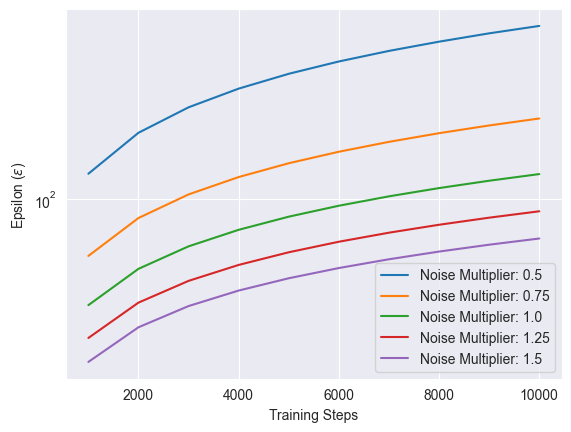

In [16]:
### DO NOT EDIT ###

for noise in noises:
    plt.plot(steps, epsilons[noise], label=f'Noise Multiplier: {noise}')
plt.legend()
plt.xlabel('Training Steps')
plt.ylabel('Epsilon ($\epsilon$)')
plt.yscale('log')
plt.show()

### DO NOT EDIT ###

### Varying Subsampling Rates

**[Task 4.2] For given range of training steps, noise multiplier and delta, plot the value of $\epsilon$ obtained for various values of the subsampling rates.**

In [17]:
### DO NOT EDIT ###

delta = 1e-6
rates = np.arange(0.02, 0.12, 0.02)
steps = np.arange(1000, 11000, 1000)
noise = 1.0
epsilons = {}

### DO NOT EDIT ###

In [ ]:
for sampling in rates:
    epss = []
    for step in steps:

        # Function call to get_epsilon() to calculate DPSGD privacy guarantee
        ### WRITE CODE HERE ###
        eps = 
        ### WRITE CODE HERE ###

        epss.append(eps)
    epsilons[sampling] = epss

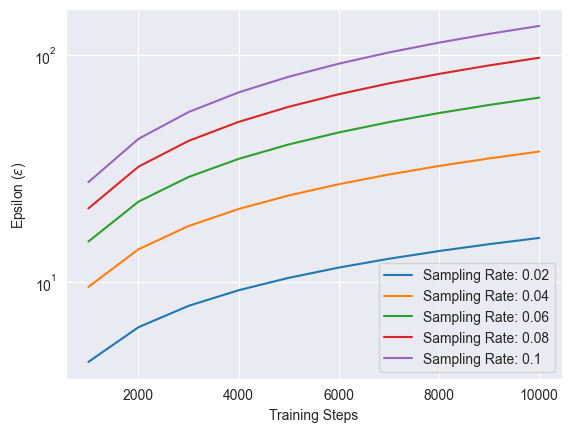

In [19]:
### DO NOT EDIT ###

for sampling in rates:
    plt.plot(steps, epsilons[sampling], label=f'Sampling Rate: {sampling}')
plt.legend()
plt.xlabel('Training Steps')
plt.ylabel('Epsilon ($\epsilon$)')
plt.yscale('log')
plt.show()

### DO NOT EDIT ###

## Calculating Optimal Noise Multipliers

In the previous task, we calculate the obtained $(\epsilon, \delta)$ guarantees for DP-SGD for a given value of noise multiplier. In this section, we calculate the optimal noise multipliers to be used to obtain certain privacy guarantees.

In order to do so we use the `scipy.optimize.brentq` optimizer which utilizes Brent's method to find the root of the function $\epsilon_{calculated}(noise)-\epsilon_{target}$ where the privacy guarantee is calculated from noise multipliers as in the previous step.

**Note**: The accountant we use in this part of the tutorial is the RDP accountant which is faster and more memory efficient as compared to the PLD accountant we have used so far. Optimization using the PLD accountant is time and memory inefficient.

**[Task 5]: Plot the optimal required noise parameters to ensure various privacy guarantees for DP SGD for the given set of sampling ratios and epsilons**

In [20]:
### DO NOT EDIT ###

def get_noise_multiplier(target_epsilon, target_delta, sampling, step):
    RDP_ORDERS = (
        [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0, 4.5]
        + list(range(5, 64))
        + [128, 256, 512]
    )
    def objective(noise_multiplier):
        accountant = rdp.RdpAccountant(RDP_ORDERS)
        dpevent = event.SelfComposedDpEvent(
            event.PoissonSampledDpEvent(
                sampling, event.GaussianDpEvent(noise_multiplier)
            ),
            step,
        )
        accountant.compose(dpevent)
        eps = accountant.get_epsilon(target_delta)
        return eps - target_epsilon

    optimal_noise = opt.brentq(objective, 1e-6, 1000)
    return optimal_noise

### DO NOT EDIT ###

In [21]:
### DO NOT EDIT ###

delta = 1e-6
rates = np.arange(0.02, 0.12, 0.02)
steps = 1000
epsil = list(np.arange(1, 10)) + list(np.arange(10, 110, 10))
noises = {}

### DO NOT EDIT ###

In [ ]:
for sampling in rates:
    noiss = []
    for eps in epsil:

        # Function call to get_noise_multiplier() to calculate optimal noise level
        ### WRITE CODE HERE ###
        noise = 
        ### WRITE CODE HERE ###

        noiss.append(noise)
    noises[sampling] = noiss

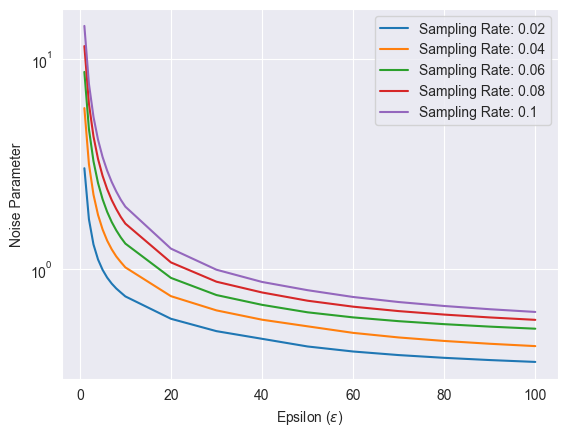

In [23]:
### DO NOT EDIT ###

for sampling in rates:
    plt.plot(epsil, noises[sampling], label=f'Sampling Rate: {sampling}')
plt.legend()
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Noise Parameter')
plt.yscale('log')
plt.show()

### DO NOT EDIT ###